## Laboratorio 3 - Regresión Logística Binaria

Este laboratorio utiliza el dataset "Observation of Species Across
the Globe" obtenido de Kaggle. Contiene 29,889 registros de
observaciones biológicas de todo el mundo con variables como
latitud, longitud, mes y año. El objetivo es clasificar si una
observación corresponde a un Animal (1) o una Planta (0)
usando regresión logística binaria.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [4]:
import pandas as pd
import numpy as np

# Cargar dataset
df = pd.read_excel('/content/drive/MyDrive/SIS420/DataSet2.xlsx')

print(f'Filas totales: {df.shape[0]}')
print(f'Columnas totales: {df.shape[1]}')
print(df.head())

Filas totales: 30825
Columnas totales: 50
       gbifID                            datasetKey  \
0  3994217800  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
1  3994112078  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
2  4006673728  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
3  4018132749  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
4  4009830713  50c9509d-22c7-4a22-a47d-8c48425ef4a7   

                                        occurrenceID   kingdom        phylum  \
0  https://www.inaturalist.org/observations/14391...   Plantae  Tracheophyta   
1  https://www.inaturalist.org/observations/14411...   Plantae  Tracheophyta   
2  https://www.inaturalist.org/observations/14435...  Animalia    Arthropoda   
3  https://www.inaturalist.org/observations/14457...   Plantae  Tracheophyta   
4  https://www.inaturalist.org/observations/14477...  Animalia      Chordata   

           class        order          family        genus  \
0  Magnoliopsida      Fabales        Fabaceae     Acmispon   
1  Magnoliopsida   Ger

In [5]:
# Seleccionar solo las columnas que necesitamos
columnas = ['decimalLatitude', 'decimalLongitude', 'month', 'year', 'kingdom']
df = df[columnas]
print(df.head())

   decimalLatitude  decimalLongitude  month  year   kingdom
0        36.683728       -121.811150     12  2022   Plantae
1        51.639157         -0.103306     12  2022   Plantae
2        35.604600        139.386767     11  2022  Animalia
3        35.885696       -106.310443     12  2022   Plantae
4       -14.550000        145.400000      8  2022  Animalia


In [6]:
# Eliminar Fungi, Chromista, etc.
df = df[df['kingdom'].isin(['Animalia', 'Plantae'])]
print(f'Filas después de filtrar: {df.shape[0]}')
print(df['kingdom'].value_counts())

Filas después de filtrar: 29955
kingdom
Animalia    17907
Plantae     12048
Name: count, dtype: int64


In [7]:
df = df.dropna()
print(f'Filas después de eliminar nulos: {df.shape[0]}')

Filas después de eliminar nulos: 29889


In [8]:
# Animalia = 1, Plantae = 0
df['y'] = (df['kingdom'] == 'Animalia').astype(int)
print(df['y'].value_counts())

y
1    17860
0    12029
Name: count, dtype: int64


In [9]:
X = df[['decimalLatitude', 'decimalLongitude', 'month', 'year']].to_numpy()
y = df['y'].to_numpy()

print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
print(f'\nPrimeros 5 ejemplos X:\n{X[:5]}')
print(f'\nPrimeros 5 ejemplos y:\n{y[:5]}')

Shape de X: (29889, 4)
Shape de y: (29889,)

Primeros 5 ejemplos X:
[[ 3.66837280e+01 -1.21811150e+02  1.20000000e+01  2.02200000e+03]
 [ 5.16391570e+01 -1.03306000e-01  1.20000000e+01  2.02200000e+03]
 [ 3.56046000e+01  1.39386767e+02  1.10000000e+01  2.02200000e+03]
 [ 3.58856960e+01 -1.06310443e+02  1.20000000e+01  2.02200000e+03]
 [-1.45500000e+01  1.45400000e+02  8.00000000e+00  2.02200000e+03]]

Primeros 5 ejemplos y:
[0 0 1 0 1]


In [10]:
#Esta función de scikit-learn divide automáticamente los datos:
#test_size=0.220% para prueba, 80% para entrenamiento
#random_state=42 Semilla aleatoria para que siempre salga igual

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para prueba
    random_state=42     # para reproducibilidad
)

print(f'Entrenamiento: {X_train.shape[0]} ejemplos')
print(f'Prueba:        {X_test.shape[0]} ejemplos')

Entrenamiento: 23911 ejemplos
Prueba:        5978 ejemplos


## Visualización de datos

Se grafican las observaciones en un mapa mundial usando latitud
y longitud. Los puntos azules representan Animalia y los verdes
Plantae. También se analiza la distribución por mes y año
para entender el comportamiento temporal de las observaciones.

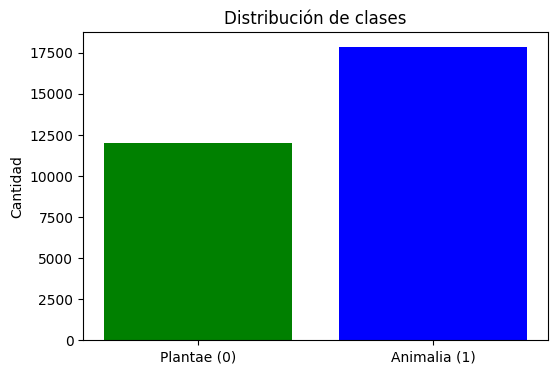

In [13]:
from matplotlib import pyplot

pyplot.figure(figsize=(6,4))
pyplot.bar(['Plantae (0)', 'Animalia (1)'],
           [(y==0).sum(), (y==1).sum()],
           color=['green', 'blue'])
pyplot.title('Distribución de clases')
pyplot.ylabel('Cantidad')
pyplot.show()

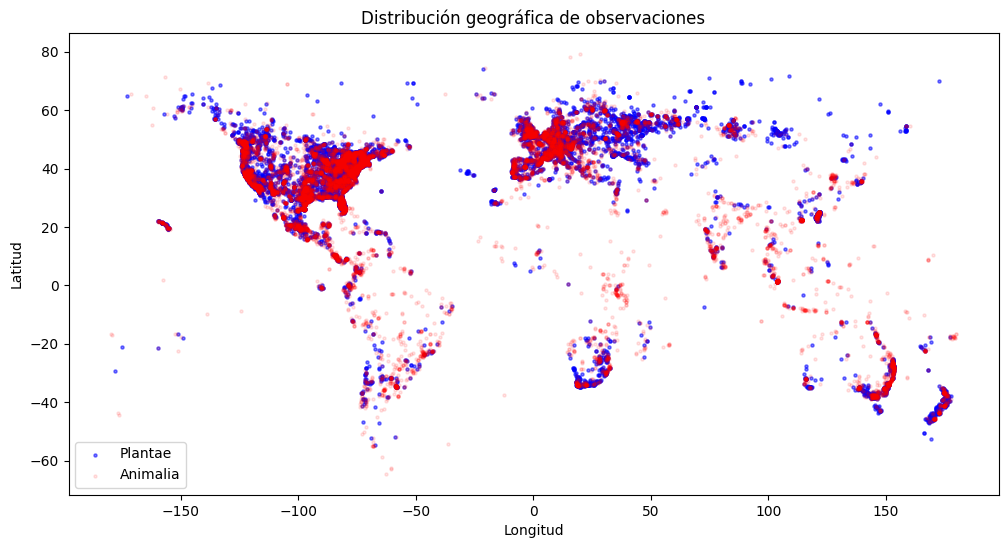

In [15]:
pyplot.figure(figsize=(12,6))
pyplot.scatter(X[y==0, 1], X[y==0, 0],
               c='blue', alpha=0.51, s=5, label='Plantae')
pyplot.scatter(X[y==1, 1], X[y==1, 0],
               c='red', alpha=0.1, s=5, label='Animalia')
pyplot.xlabel('Longitud')
pyplot.ylabel('Latitud')
pyplot.title('Distribución geográfica de observaciones')
pyplot.legend()
pyplot.show()

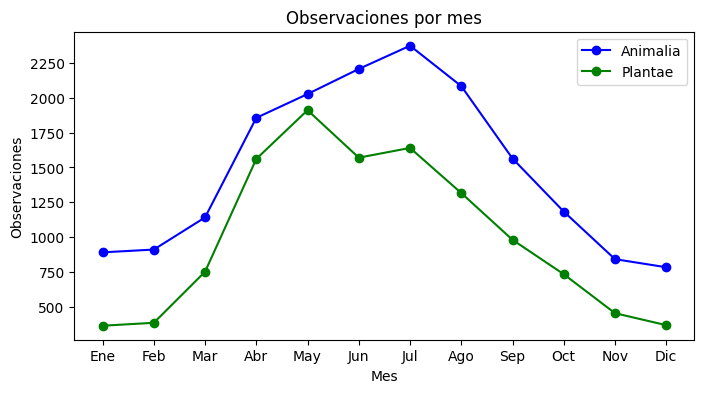

In [17]:
pyplot.figure(figsize=(8,4))
meses = range(1, 13)
animalia_mes = [((X[y==1, 2])==m).sum() for m in meses]
plantae_mes  = [((X[y==0, 2])==m).sum() for m in meses]

pyplot.plot(meses, animalia_mes, 'b-o', label='Animalia')
pyplot.plot(meses, plantae_mes,  'g-o', label='Plantae')
pyplot.xlabel('Mes')
pyplot.ylabel('Observaciones')
pyplot.title('Observaciones por mes')
pyplot.xticks(meses, ['Ene','Feb','Mar','Abr','May','Jun',
                       'Jul','Ago','Sep','Oct','Nov','Dic'])
pyplot.legend()
pyplot.show()

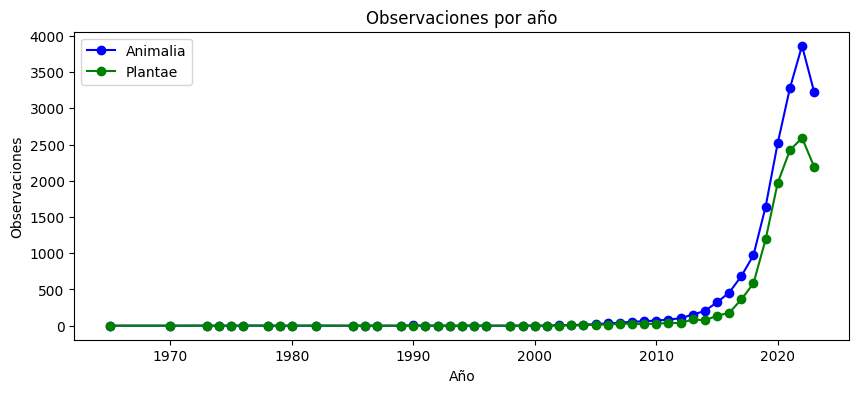

In [16]:
pyplot.figure(figsize=(10,4))
años = sorted(df['year'].unique())
animalia_año = [(df[df['kingdom']=='Animalia']['year']==a).sum() for a in años]
plantae_año  = [(df[df['kingdom']=='Plantae']['year']==a).sum() for a in años]

pyplot.plot(años, animalia_año, 'b-o', label='Animalia')
pyplot.plot(años, plantae_año,  'g-o', label='Plantae')
pyplot.xlabel('Año')
pyplot.ylabel('Observaciones')
pyplot.title('Observaciones por año')
pyplot.legend()
pyplot.show()

## Función Sigmoide

La función sigmoide es el núcleo de la regresión logística.
Convierte cualquier valor numérico en una probabilidad entre 0 y 1.
Si la probabilidad es mayor a 0.5 se clasifica como Animalia (1),
de lo contrario como Plantae (0).

In [ ]:
def sigmoid(z):
    # np.clip evita valores extremos que causan overflow
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [ ]:
print(sigmoid(-100))  # → casi 0.0  (definitivamente Plantae)
print(sigmoid(0))     # → 0.5       (indeciso)
print(sigmoid(100))   # → casi 1.0  (definitivamente Animalia)

3.7200759760208356e-44
0.5
1.0


## Función de Costo

A diferencia de la regresión lineal, la regresión logística usa
logaritmos para medir el error. Esto garantiza un único mínimo
global. El costo inicial fue 0.6931, equivalente a un modelo
que no sabe nada (50/50).

In [ ]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    # np.clip evita log(0) que causa división por cero
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = -(1/m) * (y.dot(np.log(h)) + (1-y).dot(np.log(1-h)))
    return J

In [ ]:
from sklearn.preprocessing import StandardScaler

# Crear el normalizador
scaler = StandardScaler()

# Normalizar X_train y X_test
# IMPORTANTE: fit solo con train, transform a ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Agregar columna de unos después de normalizar
X_train_b = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_b  = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

print('Antes de normalizar:')
print(f'  Media year: {X_train[:, 3].mean():.2f}')
print(f'\nDespués de normalizar:')
print(f'  Media year: {X_train_scaled[:, 3].mean():.4f}')

# Theta inicial en ceros
theta = np.zeros(X_train_b.shape[1])



# Calcular costo inicial
J = calcularCosto(theta, X_train_b, y_train)
print(f'Costo inicial con theta=0: {J:.4f}')
# Debería dar aproximadamente 0.6931

Antes de normalizar:
  Media year: 2020.26

Después de normalizar:
  Media year: 0.0000
Costo inicial con theta=0: 0.6931


## Gradient Descent

Se utilizó alpha=1.0 y 10,000 iteraciones con datos normalizados
mediante StandardScaler. El costo bajó de 0.6931 a 0.6701.
La mejora fue limitada porque animales y plantas coexisten en
las mismas coordenadas geográficas, dificultando su separación lineal.

In [ ]:
def gradientDescent(X, y, theta, alpha, num_iters):

    # Número de ejemplos de entrenamiento
    m = y.size

    # Copia theta para no modificar el original
    # (numpy pasa arrays por referencia)
    theta = theta.copy()

    # Lista para guardar el costo en cada iteración
    # nos permite ver si el modelo va mejorando
    J_history = []

    for i in range(num_iters):

        # Calcula las predicciones actuales
        # sigmoid convierte los valores a probabilidades entre 0 y 1
        h = sigmoid(X.dot(theta))

        # Actualiza theta en la dirección que reduce el costo
        # alpha  → controla el tamaño del paso
        # X.T    → transpuesta de X para que las dimensiones coincidan
        # h - y  → error entre predicción y valor real
        theta = theta - (alpha / m) * X.T.dot(h - y)

        # Guarda el costo actual para graficar después
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

In [ ]:
theta_inicial = np.zeros(X_train_b.shape[1])

for alpha in [1.0, 0.5, 0.1, 0.01]:
    theta_temp, J_history_temp = gradientDescent(
        X_train_b, y_train, theta_inicial, alpha, num_iters=1500)
    print(f'Alpha: {alpha} → Costo final: {J_history_temp[-1]:.4f}')


Alpha: 1.0 → Costo final: 0.6701
Alpha: 0.5 → Costo final: 0.6701
Alpha: 0.1 → Costo final: 0.6701
Alpha: 0.01 → Costo final: 0.6702


/tmp/ipykernel_187/1122282195.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pyplot.legend()


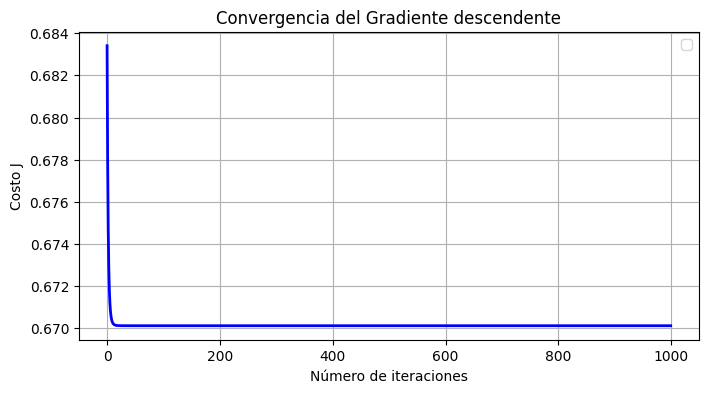

Costo inicial: 0.6931
Costo final:   0.6701
Mejora:        3.32%


In [ ]:
# Ejecutar gradient descent
theta_final, J_history = gradientDescent(
    X_train_b, y_train, np.zeros(X_train_b.shape[1]),
    alpha=1.0, num_iters=1000)

# Graficar la convergencia
pyplot.figure(figsize=(8,4))

# Graficar el costo en cada iteración
pyplot.plot(J_history, 'b-', lw=2)

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Gradiente descendente')
pyplot.legend()
pyplot.grid(True)
pyplot.show()
print(f'Costo inicial: 0.6931')
print(f'Costo final:   {J_history[-1]:.4f}')
print(f'Mejora:        {((0.6931 - J_history[-1])/0.6931)*100:.2f}%')


## Predicciones y Validación

Se evaluó el modelo con el 20% de datos de prueba (5,978 ejemplos).
La precisión obtenida fue del 59.62%. El modelo presentó sesgo
hacia la clase mayoritaria (Animalia 60%), prediciendo correctamente
casi todos los animales pero fallando en plantas grasticamente.

In [ ]:
def predecir(theta, X):
    # Calcula probabilidades con sigmoid
    probabilidades = sigmoid(X.dot(theta))
    # Si probabilidad >= 0.5 → Animalia (1), sino Plantae (0)
    return (probabilidades >= 0.5).astype(int)

# Predecir con datos de prueba
y_pred = predecir(theta_final, X_test_b)

# Precisión general
precision = (y_pred == y_test).mean() * 100
print(f'Precisión del modelo: {precision:.2f}%')

# Detalle de predicciones
print(f'\nDe {y_test.size} ejemplos de prueba:')
print(f'  Correctos:   {(y_pred == y_test).sum()}')
print(f'  Incorrectos: {(y_pred != y_test).sum()}')

# Precisión por clase
print(f'\nPor clase:')
print(f'  Animalia correctos: {((y_pred==1) & (y_test==1)).sum()} de {(y_test==1).sum()}')
print(f'  Plantae correctos:  {((y_pred==0) & (y_test==0)).sum()} de {(y_test==0).sum()}')

Precisión del modelo: 59.62%

De 5978 ejemplos de prueba:
  Correctos:   3564
  Incorrectos: 2414

Por clase:
  Animalia correctos: 3 de 2414
  Plantae correctos:  3561 de 3564


Conclusión:
El modelo de regresión logística no fue efectivo para distinguir entre Animalia y Plantae usando latitud, longitud, month y year como variables. Esto se debe a tres razones principales:
1. Variables poco discriminativas
La ubicación geográfica y el mes no son suficientes para separar animales de plantas, ya que ambos coexisten en las mismas coordenadas del mundo como podemos ver en el grafico siguiente.
2. Sesgo de clase
Con 60% Animalia vs 40% Plantae, el modelo aprendió a predecir siempre Animalia para minimizar el error, ignorando completamente a Plantae.
3. No separabilidad lineal
La regresión logística busca una línea recta que separe las clases. Animales y plantas no son separables linealmente con estas variables.

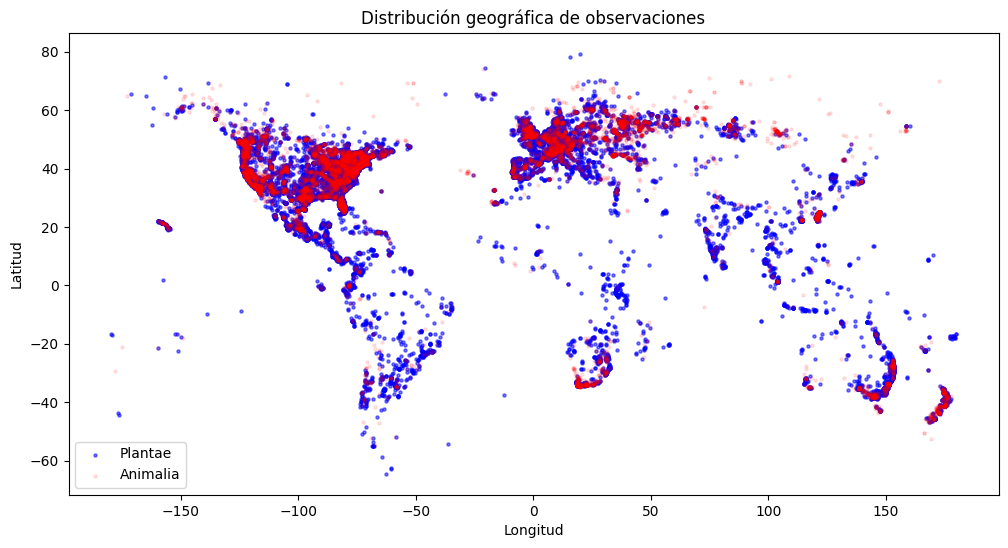

In [ ]:
pyplot.figure(figsize=(12,6))
pyplot.scatter(X[y==0, 1], X[y==0, 0],
               c='blue', alpha=0.51, s=5, label='Plantae')
pyplot.scatter(X[y==1, 1], X[y==1, 0],
               c='red', alpha=0.1, s=5, label='Animalia')
pyplot.xlabel('Longitud')
pyplot.ylabel('Latitud')
pyplot.title('Distribución geográfica de observaciones')
pyplot.legend()
pyplot.show()